Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        47

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

Confusion Matrix:
 [[53  0]
 [ 0 47]]


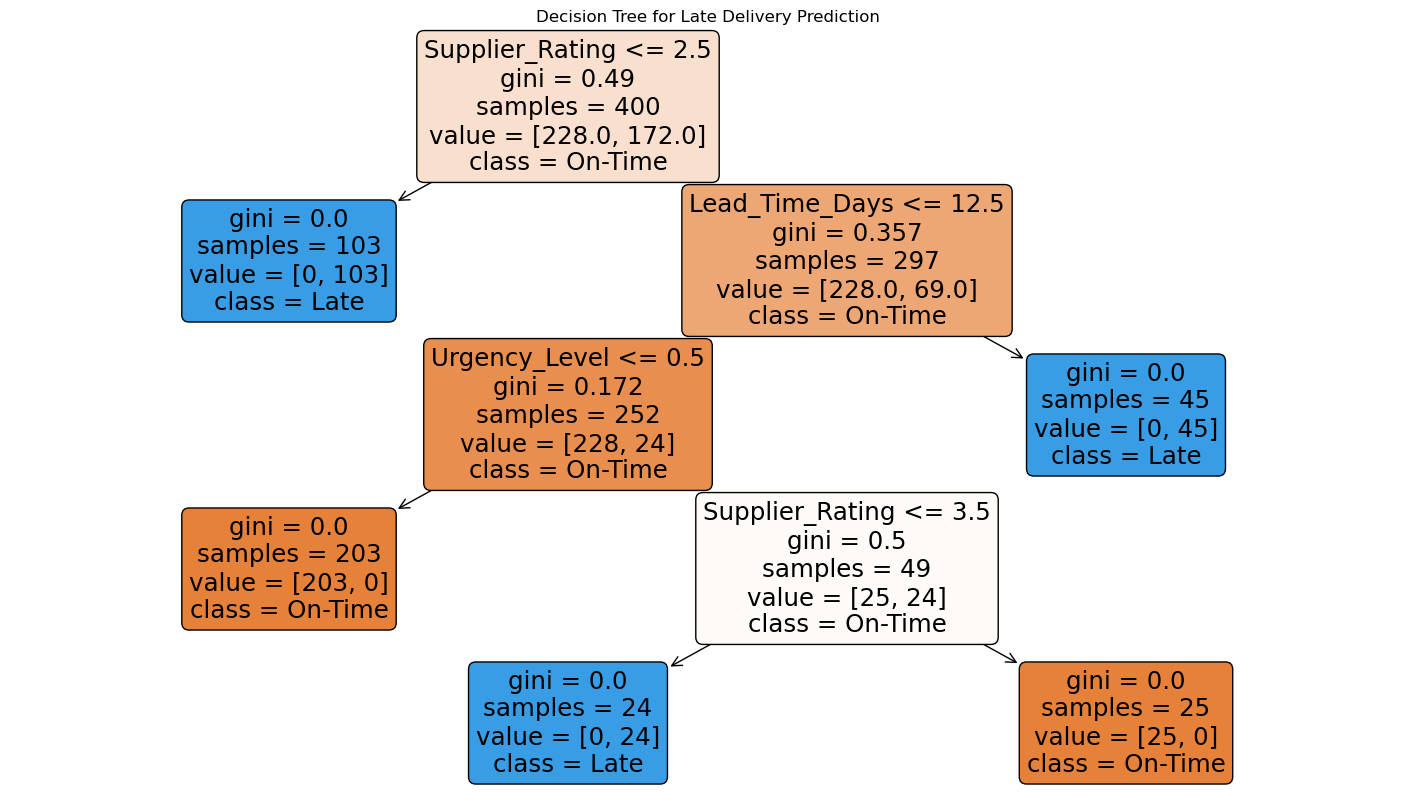


Decision Rules from Tree:

|--- Supplier_Rating <= 2.50
|   |--- class: 1
|--- Supplier_Rating >  2.50
|   |--- Lead_Time_Days <= 12.50
|   |   |--- Urgency_Level <= 0.50
|   |   |   |--- class: 0
|   |   |--- Urgency_Level >  0.50
|   |   |   |--- Supplier_Rating <= 3.50
|   |   |   |   |--- class: 1
|   |   |   |--- Supplier_Rating >  3.50
|   |   |   |   |--- class: 0
|   |--- Lead_Time_Days >  12.50
|   |   |--- class: 1


Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


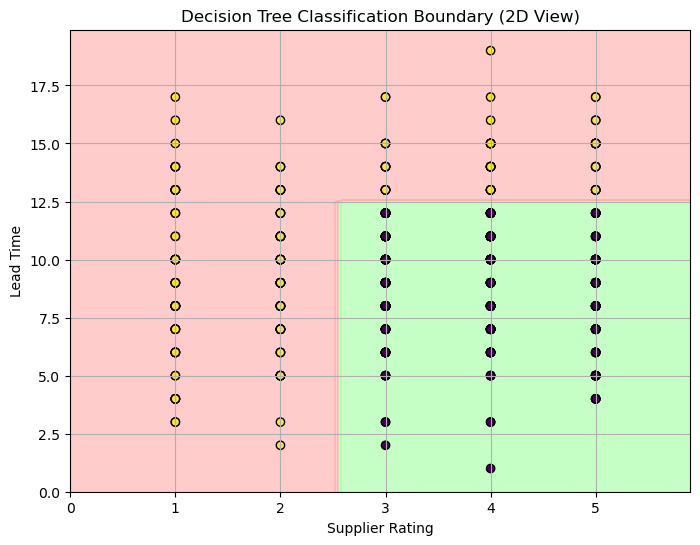

In [3]:
# 📦 Procurement Late Delivery Classifier using Decision Tree

"""
This notebook demonstrates a step-by-step implementation of a Decision Tree Classifier
to predict whether a procurement Purchase Order (PO) will be delivered late.
The model uses supplier ratings, lead time, urgency level, etc. to build a rule-based tree.

Use case: Supply Chain teams can proactively identify high-risk orders before they cause disruptions.
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ----------------------------------------------------
# 1. Simulate Procurement Data
# ----------------------------------------------------

np.random.seed(42)
n = 500  # number of POs

# Simulate realistic PO data with supplier rating and urgency
df = pd.DataFrame({
    'PO_ID': [f'PO_{i:04d}' for i in range(n)],
    'Supplier_Rating': np.random.choice([1, 2, 3, 4, 5], size=n, p=[0.1, 0.15, 0.3, 0.25, 0.2]),
    'Lead_Time_Days': np.random.normal(loc=10, scale=3, size=n).astype(int),
    'Material_Importance': np.random.choice(['Low', 'Medium', 'High'], size=n, p=[0.3, 0.4, 0.3]),
    'PO_Value_EUR': np.random.normal(loc=5000, scale=1500, size=n).astype(int),
    'Urgency_Level': np.random.choice(['Normal', 'Urgent'], size=n, p=[0.8, 0.2])
})

# Rule-based label: simulate if PO is likely to be late
# Logic: Low-rated suppliers, high lead time, urgent orders from mid-tier suppliers
df['Late_Delivery'] = (
    (df['Supplier_Rating'] <= 2) |
    (df['Lead_Time_Days'] > 12) |
    ((df['Urgency_Level'] == 'Urgent') & (df['Supplier_Rating'] < 4))
).astype(int)

# ----------------------------------------------------
# 2. Data Preprocessing
# ----------------------------------------------------
from sklearn.preprocessing import LabelEncoder

# Encode categorical features
le = LabelEncoder()
df['Material_Importance'] = le.fit_transform(df['Material_Importance'])
df['Urgency_Level'] = le.fit_transform(df['Urgency_Level'])

# Define features and target
X = df[['Supplier_Rating', 'Lead_Time_Days', 'Material_Importance', 'PO_Value_EUR', 'Urgency_Level']]
y = df['Late_Delivery']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ----------------------------------------------------
# 3. Train Decision Tree Classifier
# ----------------------------------------------------

# Initialize tree with max depth to control complexity
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# ----------------------------------------------------
# 4. Evaluate Model Performance
# ----------------------------------------------------

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ----------------------------------------------------
# 5. Visualize Decision Tree Structure
# ----------------------------------------------------

plt.figure(figsize=(18, 10))
plot_tree(clf,
          feature_names=X.columns,
          class_names=["On-Time", "Late"],
          filled=True, rounded=True)
plt.title("Decision Tree for Late Delivery Prediction")
plt.show()

# ----------------------------------------------------
# 6. Extract Human-Readable Rules
# ----------------------------------------------------

rules = export_text(clf, feature_names=list(X.columns), max_depth=4)
print("\nDecision Rules from Tree:\n")
print(rules)

# ----------------------------------------------------
# 7. Hyperparameter Tuning with GridSearchCV
# ----------------------------------------------------

# Try different combinations of max depth, split sizes, and criteria
param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3],
    'criterion': ['gini', 'entropy']
}

grid_clf = GridSearchCV(DecisionTreeClassifier(random_state=42),
                        param_grid,
                        scoring='accuracy',
                        cv=5)
grid_clf.fit(X_train, y_train)

print("\nBest Parameters:", grid_clf.best_params_)

# ----------------------------------------------------
# 8. Visualize Decision Boundary (2D Example)
# ----------------------------------------------------

# Use only two features to visualize the decision regions
X_vis = X[['Supplier_Rating', 'Lead_Time_Days']]
y_vis = y

clf_vis = DecisionTreeClassifier(max_depth=3)
clf_vis.fit(X_vis, y_vis)

# Create mesh grid for plotting
x_min, x_max = X_vis.iloc[:, 0].min()-1, X_vis.iloc[:, 0].max()+1
y_min, y_max = X_vis.iloc[:, 1].min()-1, X_vis.iloc[:, 1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = clf_vis.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot decision surface
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=ListedColormap(["#A0FFA0", "#FFAAAA"]), alpha=0.6)
plt.scatter(X_vis.iloc[:, 0], X_vis.iloc[:, 1], c=y_vis, edgecolor='k')
plt.xlabel("Supplier Rating")
plt.ylabel("Lead Time")
plt.title("Decision Tree Classification Boundary (2D View)")
plt.grid()
plt.show()
